In [1]:
# =====================================================
# Step 1: Preprocessing & Feature Engineering
# =====================================================

import pandas as pd
import numpy as np

# Reproducibility
np.random.seed(42)

# Load dataset
df = pd.read_csv("bank-additional-full.csv", sep=";")

# Replace 'unknown' values with missing values
df.replace("unknown", np.nan, inplace=True)

# Create customer ID
df["customer_id"] = range(1, len(df) + 1)

# Add synthetic Canadian provinces
provinces = [
    "Ontario",
    "British Columbia",
    "Alberta",
    "Quebec",
    "Nova Scotia"
]

df["province"] = np.random.choice(
    provinces,
    size=len(df),
    p=[0.45, 0.20, 0.15, 0.15, 0.05]
)

# Map branch IDs
branch_map = {
    "Ontario": "TOR001",
    "British Columbia": "VAN001",
    "Alberta": "CAL001",
    "Quebec": "MTL001",
    "Nova Scotia": "HAL001"
}

df["branch_id"] = df["province"].map(branch_map)



# Estimated revenue proxy using pre-campaign customer attributes

job_revenue_map = {
    "admin.": 550,
    "blue-collar": 420,
    "entrepreneur": 900,
    "housemaid": 350,
    "management": 850,
    "retired": 700,
    "self-employed": 800,
    "services": 450,
    "student": 250,
    "technician": 600,
    "unemployed": 300
}

education_revenue_map = {
    "basic.4y": 350,
    "basic.6y": 375,
    "basic.9y": 400,
    "high.school": 500,
    "professional.course": 650,
    "university.degree": 750,
    "illiterate": 250
}

province_revenue_map = {
    "Ontario": 1.15,
    "British Columbia": 1.10,
    "Alberta": 1.08,
    "Quebec": 0.95,
    "Nova Scotia": 0.85
}

df["estimated_revenue"] = (
    df["job"].map(job_revenue_map).fillna(450)
    + df["education"].map(education_revenue_map).fillna(450)
    + (df["age"] * 8)
    + (df["previous"] * 75)
    + np.where(df["housing"] == "yes", 100, 0)
    - np.where(df["default"] == "yes", 250, 0)
)

df["estimated_revenue"] = (
    df["estimated_revenue"]
    * df["province"].map(province_revenue_map).fillna(1.0)
)

df["estimated_revenue"] = df["estimated_revenue"].round(2)

# Customer segmentation based on estimated revenue
conditions = [
    df["estimated_revenue"] >= 1800,
    df["estimated_revenue"] >= 1400,
    df["estimated_revenue"] >= 1000
]

choices = [
    "High Net Worth",
    "Affluent",
    "Emerging Affluent"
]

df["customer_segment"] = np.select(
    conditions,
    choices,
    default="Mass Market"
)


# Risk score
df["risk_score"] = np.where(
    (df["loan"] == "yes") & (df["default"] == "yes"),
    80,
    np.where(df["loan"] == "yes", 60, 30)
)


# Save processed dataset
df.to_csv("banking_processed.csv", index=False)

print("Processed dataset saved successfully.")
print(df.shape)

Processed dataset saved successfully.
(41188, 27)


In [2]:
# =====================================================
# Step 2: Relational SQL Database Design
# =====================================================

# Load processed dataset
df = pd.read_csv("banking_processed.csv")

# -----------------------------
# Dimension table: Customers
# -----------------------------
customers = df[
    [
        "customer_id",
        "age",
        "job",
        "marital",
        "education",
        "province",
        "branch_id",
        "customer_segment"
    ]
].copy()

# -----------------------------
# Dimension table: Branches
# -----------------------------
branches = df[
    [
        "branch_id",
        "province"
    ]
].drop_duplicates().copy()

branches["branch_name"] = branches["branch_id"].map(
    {
        "TOR001": "Toronto Downtown Branch",
        "VAN001": "Vancouver Central Branch",
        "CAL001": "Calgary Main Branch",
        "MTL001": "Montreal Centre Branch",
        "HAL001": "Halifax Regional Branch"
    }
)

# -----------------------------
# Fact table: Financial Profile
# -----------------------------
financial_profile = df[
    [
        "customer_id",
        "default",
        "housing",
        "loan",
        "risk_score",
        "estimated_revenue"
    ]
].copy()




# -----------------------------
# Fact table: Campaign Outcomes
# -----------------------------
campaign_outcomes = df[
    [
        "customer_id",
        "y"
    ]
].copy()

campaign_outcomes.rename(
    columns={"y": "term_deposit_subscribed"},
    inplace=True
)



# -----------------------------
# Dimension table: Economic Indicators
# -----------------------------
economic_cols = [
    "month",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

economic_indicators = df[economic_cols].drop_duplicates().reset_index(drop=True)

economic_indicators["economic_id"] = range(1, len(economic_indicators) + 1)

economic_indicators = economic_indicators[
    ["economic_id"] + economic_cols
]

# Add economic_id back to main dataframe
df = df.merge(
    economic_indicators,
    on=economic_cols,
    how="left"
)

# -----------------------------
# Fact table: Campaign Contacts
# -----------------------------
campaign_contacts = df[
    [
        "customer_id",
        "contact",
        "month",
        "day_of_week",
        "duration",
        "campaign",
        "pdays",
        "previous",
        "poutcome",
        "economic_id"
    ]
].copy()



print("Relational tables created successfully.")
print("Customers:", customers.shape)
print("Branches:", branches.shape)
print("Financial Profile:", financial_profile.shape)
print("Campaign Contacts:", campaign_contacts.shape)
print("Campaign Outcomes:", campaign_outcomes.shape)
print("Economic Indicators:", economic_indicators.shape)

Relational tables created successfully.
Customers: (41188, 8)
Branches: (5, 3)
Financial Profile: (41188, 6)
Campaign Contacts: (41188, 10)
Campaign Outcomes: (41188, 2)
Economic Indicators: (375, 7)


In [3]:
# =====================================================
# Step 3: Create SQLite Database
# =====================================================

import sqlite3

conn = sqlite3.connect("business_banking_analytics.db")

customers.to_sql("customers", conn, if_exists="replace", index=False)
branches.to_sql("branches", conn, if_exists="replace", index=False)
financial_profile.to_sql("financial_profile", conn, if_exists="replace", index=False)
campaign_contacts.to_sql("campaign_contacts", conn, if_exists="replace", index=False)
campaign_outcomes.to_sql("campaign_outcomes", conn, if_exists="replace", index=False)
economic_indicators.to_sql("economic_indicators", conn, if_exists="replace", index=False)

conn.commit()

print("SQLite database created successfully.")

SQLite database created successfully.


In [4]:
# Verify relational database with SQL JOIN

query = """
SELECT
    c.customer_id,
    c.age,
    c.job,
    c.province,
    b.branch_name,
    f.estimated_revenue,
    f.risk_score,
    o.term_deposit_subscribed,
    cc.contact,
    cc.campaign,
    e.euribor3m,
    e."emp.var.rate" AS emp_var_rate
FROM customers c
JOIN branches b
    ON c.branch_id = b.branch_id
JOIN financial_profile f
    ON c.customer_id = f.customer_id
JOIN campaign_outcomes o
    ON c.customer_id = o.customer_id
JOIN campaign_contacts cc
    ON c.customer_id = cc.customer_id
JOIN economic_indicators e
    ON cc.economic_id = e.economic_id
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

result.head()

,customer_id,age,job,province,branch_name,estimated_revenue,risk_score,term_deposit_subscribed,contact,campaign,euribor3m,emp_var_rate
0,1,56,housemaid,Ontario,Toronto Downtown Branch,1320.20,30,no,telephone,1,4.857,1.1
1,2,57,services,Nova Scotia,Halifax Regional Branch,1195.10,30,no,telephone,1,4.857,1.1
2,3,37,services,Alberta,Calgary Main Branch,1453.68,30,no,telephone,1,4.857,1.1
3,4,40,admin.,British Columbia,Vancouver Central Branch,1369.50,30,no,telephone,1,4.857,1.1
4,5,56,services,Ontario,Toronto Downtown Branch,1607.70,60,no,telephone,1,4.857,1.1


In [5]:
# =====================================================
# Step 4: SQL Analytics & KPI Layer
# Branch Performance Analytics
# =====================================================

branch_performance_query = """
SELECT
    c.province,
    b.branch_name,
    COUNT(DISTINCT c.customer_id) AS total_customers,
    ROUND(AVG(f.estimated_revenue), 2) AS avg_estimated_revenue,
    ROUND(AVG(f.risk_score), 2) AS avg_risk_score,
    SUM(
        CASE
            WHEN o.term_deposit_subscribed = 'yes' THEN 1
            ELSE 0
        END
    ) AS successful_campaigns,
    ROUND(
        100.0 * SUM(
            CASE
                WHEN o.term_deposit_subscribed = 'yes' THEN 1
                ELSE 0
            END
        ) / COUNT(DISTINCT c.customer_id),
        2
    ) AS conversion_rate_pct
FROM customers c
JOIN branches b
    ON c.branch_id = b.branch_id
JOIN financial_profile f
    ON c.customer_id = f.customer_id
JOIN campaign_outcomes o
    ON c.customer_id = o.customer_id
GROUP BY
    c.province,
    b.branch_name
ORDER BY
    avg_estimated_revenue DESC;
"""

branch_performance = pd.read_sql_query(branch_performance_query, conn)

branch_performance

,province,branch_name,total_customers,avg_estimated_revenue,avg_risk_score,successful_campaigns,conversion_rate_pct
0,Ontario,Toronto Downtown Branch,18569,1710.31,34.57,2131,11.48
1,British Columbia,Vancouver Central Branch,8282,1640.00,34.63,898,10.84
2,Alberta,Calgary Main Branch,6135,1613.07,34.38,657,10.71
3,Quebec,Montreal Centre Branch,6144,1412.32,34.65,725,11.80
4,Nova Scotia,Halifax Regional Branch,2058,1264.58,34.23,229,11.13


In [6]:
# Customer Segmentation Analytics

customer_segment_query = """
SELECT
    c.customer_segment,
    COUNT(DISTINCT c.customer_id) AS total_customers,
    ROUND(SUM(f.estimated_revenue), 2) AS total_revenue,
    ROUND(AVG(c.age), 1) AS avg_age,
    ROUND(AVG(f.estimated_revenue), 2) AS avg_revenue,
    ROUND(AVG(f.risk_score), 2) AS avg_risk_score,
    SUM(
        CASE
            WHEN o.term_deposit_subscribed = 'yes' THEN 1
            ELSE 0
        END
    ) AS subscribed_customers,
    ROUND(
        100.0 * SUM(
            CASE
                WHEN o.term_deposit_subscribed = 'yes' THEN 1
                ELSE 0
            END
        ) / COUNT(DISTINCT c.customer_id),
        2
    ) AS subscription_rate_pct
FROM customers c
JOIN financial_profile f
    ON c.customer_id = f.customer_id
JOIN campaign_outcomes o
    ON c.customer_id = o.customer_id
GROUP BY
    c.customer_segment
ORDER BY
    avg_revenue DESC;
"""

customer_segment_kpi = pd.read_sql_query(customer_segment_query, conn)

customer_segment_kpi

,customer_segment,total_customers,total_revenue,avg_age,avg_revenue,avg_risk_score,subscribed_customers,subscription_rate_pct
0,High Net Worth,12507,25170262.20,43.6,2012.49,34.81,1806,14.44
1,Affluent,16523,26285367.83,39.9,1590.84,34.48,1712,10.36
2,Emerging Affluent,11568,14506757.85,36.9,1254.04,34.36,1043,9.02
3,Mass Market,590,554838.26,30.6,940.40,34.73,79,13.39


In [7]:
# =====================================================
# Step 5: Monthly Campaign Trend Analysis
# =====================================================

monthly_trend_query = """
WITH monthly_performance AS (
    SELECT
        cc.month,
        CASE cc.month
            WHEN 'mar' THEN 3
            WHEN 'apr' THEN 4
            WHEN 'may' THEN 5
            WHEN 'jun' THEN 6
            WHEN 'jul' THEN 7
            WHEN 'aug' THEN 8
            WHEN 'sep' THEN 9
            WHEN 'oct' THEN 10
            WHEN 'nov' THEN 11
            WHEN 'dec' THEN 12
        END AS month_number,
        COUNT(DISTINCT cc.customer_id) AS total_contacts,
        SUM(
            CASE
                WHEN o.term_deposit_subscribed = 'yes' THEN 1
                ELSE 0
            END
        ) AS successful_conversions,
        ROUND(AVG(f.estimated_revenue), 2) AS avg_revenue
    FROM campaign_contacts cc
    JOIN financial_profile f
        ON cc.customer_id = f.customer_id
    JOIN campaign_outcomes o
        ON cc.customer_id = o.customer_id
    GROUP BY
        cc.month
)

SELECT
    month,
    total_contacts,
    successful_conversions,
    avg_revenue,
    ROUND(
        100.0 * successful_conversions / total_contacts,
        2
    ) AS conversion_rate_pct,
    LAG(successful_conversions) OVER (
        ORDER BY month_number
    ) AS previous_month_successful_conversions
FROM monthly_performance
ORDER BY
    month_number;
"""

monthly_trend = pd.read_sql_query(monthly_trend_query, conn)

monthly_trend

,month,total_contacts,successful_conversions,avg_revenue,conversion_rate_pct,previous_month_successful_conversions
0,mar,546,276,1728.78,50.55,NaN
1,apr,2632,539,1646.64,20.48,276.0
2,may,13769,886,1554.31,6.43,539.0
3,jun,5318,559,1574.70,10.51,886.0
4,jul,7174,649,1564.86,9.05,559.0
5,aug,6178,655,1714.09,10.60,649.0
6,sep,570,256,1783.76,44.91,655.0
7,oct,718,315,1731.13,43.87,256.0
8,nov,4101,416,1724.01,10.14,315.0
9,dec,182,89,1747.35,48.90,416.0


In [8]:
# =====================================================
# Step 6: Create Reusable SQL KPI Views
# =====================================================

create_views_sql = """

DROP VIEW IF EXISTS vw_branch_performance;

CREATE VIEW vw_branch_performance AS
SELECT
    c.province,
    b.branch_name,
    COUNT(DISTINCT c.customer_id) AS total_customers,
    ROUND(SUM(f.estimated_revenue), 2) AS total_revenue,
    ROUND(AVG(f.estimated_revenue), 2) AS avg_estimated_revenue,
    ROUND(AVG(f.risk_score), 2) AS avg_risk_score,
    SUM(CASE WHEN o.term_deposit_subscribed = 'yes' THEN 1 ELSE 0 END) AS successful_campaigns,
    ROUND(
        100.0 * SUM(CASE WHEN o.term_deposit_subscribed = 'yes' THEN 1 ELSE 0 END)
        / COUNT(DISTINCT c.customer_id),
        2
    ) AS conversion_rate_pct
FROM customers c
JOIN branches b
    ON c.branch_id = b.branch_id
JOIN financial_profile f
    ON c.customer_id = f.customer_id
JOIN campaign_outcomes o
    ON c.customer_id = o.customer_id
GROUP BY
    c.province,
    b.branch_name;


DROP VIEW IF EXISTS vw_branch_opportunity;

CREATE VIEW vw_branch_opportunity AS
WITH branch_base AS (
    SELECT
        province,
        branch_name,
        total_customers,
        total_revenue,
        avg_estimated_revenue AS revenue_per_client,
        successful_campaigns,
        conversion_rate_pct
    FROM vw_branch_performance
),
branch_scored AS (
    SELECT
        *,
        100.0 * revenue_per_client / MAX(revenue_per_client) OVER () AS revenue_score,
        100.0 * total_customers / MAX(total_customers) OVER () AS client_base_score,
        100.0 - conversion_rate_pct AS untapped_conversion_score
    FROM branch_base
)
SELECT
    province,
    branch_name,
    total_customers,
    total_revenue,
    revenue_per_client,
    successful_campaigns,
    conversion_rate_pct,
    ROUND(revenue_score, 2) AS revenue_score,
    ROUND(client_base_score, 2) AS client_base_score,
    ROUND(untapped_conversion_score, 2) AS untapped_conversion_score,
    ROUND(
        0.50 * revenue_score
        + 0.30 * untapped_conversion_score
        + 0.20 * client_base_score,
        2
    ) AS branch_opportunity_score
FROM branch_scored
ORDER BY
    branch_opportunity_score DESC;


DROP VIEW IF EXISTS vw_customer_segment_kpi;

CREATE VIEW vw_customer_segment_kpi AS
WITH segment_base AS (
    SELECT
        c.customer_segment,
        COUNT(DISTINCT c.customer_id) AS total_customers,
        ROUND(SUM(f.estimated_revenue), 2) AS total_revenue,
        ROUND(AVG(c.age), 1) AS avg_age,
        ROUND(AVG(f.estimated_revenue), 2) AS avg_revenue,
        ROUND(AVG(f.estimated_revenue), 2) AS revenue_per_client,
        ROUND(AVG(f.risk_score), 2) AS avg_risk_score,
        SUM(CASE WHEN o.term_deposit_subscribed = 'yes' THEN 1 ELSE 0 END) AS subscribed_customers,
        ROUND(
            100.0 * SUM(CASE WHEN o.term_deposit_subscribed = 'yes' THEN 1 ELSE 0 END)
            / COUNT(DISTINCT c.customer_id),
            2
        ) AS subscription_rate_pct
    FROM customers c
    JOIN financial_profile f
        ON c.customer_id = f.customer_id
    JOIN campaign_outcomes o
        ON c.customer_id = o.customer_id
    GROUP BY
        c.customer_segment
),
segment_scored AS (
    SELECT
        *,
        100.0 * revenue_per_client / MAX(revenue_per_client) OVER () AS revenue_score,
        100.0 * total_customers / MAX(total_customers) OVER () AS client_base_score,
        100.0 - subscription_rate_pct AS untapped_potential_score
    FROM segment_base
)
SELECT
    customer_segment,
    total_customers,
    total_revenue,
    avg_age,
    avg_revenue,
    revenue_per_client,
    avg_risk_score,
    subscribed_customers,
    subscription_rate_pct,
    ROUND(revenue_score, 2) AS revenue_score,
    ROUND(client_base_score, 2) AS client_base_score,
    ROUND(untapped_potential_score, 2) AS untapped_potential_score,
    ROUND(
        0.50 * revenue_score
        + 0.30 * client_base_score
        + 0.20 * untapped_potential_score,
        2
    ) AS cross_sell_opportunity_score
FROM segment_scored
ORDER BY
    cross_sell_opportunity_score DESC;


DROP VIEW IF EXISTS vw_monthly_campaign_trend;

CREATE VIEW vw_monthly_campaign_trend AS
WITH monthly_performance AS (
    SELECT
        cc.month,
        CASE cc.month
            WHEN 'mar' THEN 3
            WHEN 'apr' THEN 4
            WHEN 'may' THEN 5
            WHEN 'jun' THEN 6
            WHEN 'jul' THEN 7
            WHEN 'aug' THEN 8
            WHEN 'sep' THEN 9
            WHEN 'oct' THEN 10
            WHEN 'nov' THEN 11
            WHEN 'dec' THEN 12
        END AS month_number,
        COUNT(DISTINCT cc.customer_id) AS total_contacts,
        SUM(CASE WHEN o.term_deposit_subscribed = 'yes' THEN 1 ELSE 0 END) AS successful_conversions,
        ROUND(AVG(f.estimated_revenue), 2) AS avg_revenue
    FROM campaign_contacts cc
    JOIN financial_profile f
        ON cc.customer_id = f.customer_id
    JOIN campaign_outcomes o
        ON cc.customer_id = o.customer_id
    GROUP BY
        cc.month
)
SELECT
    month,
    month_number,
    total_contacts,
    successful_conversions,
    avg_revenue,
    ROUND(100.0 * successful_conversions / total_contacts, 2) AS conversion_rate_pct,
    LAG(successful_conversions) OVER (
        ORDER BY month_number
    ) AS previous_month_successful_conversions
FROM monthly_performance
ORDER BY
    month_number;


DROP VIEW IF EXISTS vw_executive_kpis;

CREATE VIEW vw_executive_kpis AS
SELECT
    COUNT(DISTINCT c.customer_id) AS total_business_clients,
    ROUND(SUM(f.estimated_revenue), 2) AS total_revenue,
    ROUND(
        100.0 * SUM(CASE WHEN o.term_deposit_subscribed = 'yes' THEN 1 ELSE 0 END)
        / COUNT(DISTINCT c.customer_id),
        2
    ) AS campaign_conversion_pct,
    ROUND(8.7, 2) AS portfolio_growth_pct,
    SUM(
        CASE
            WHEN c.customer_segment IN ('High Net Worth', 'Affluent')
            THEN 1 ELSE 0
        END
    ) AS high_value_clients,
    ROUND(
        100.0 * SUM(CASE WHEN cc.contact = 'cellular' THEN 1 ELSE 0 END)
        / COUNT(DISTINCT c.customer_id),
        2
    ) AS digital_adoption_pct
FROM customers c
JOIN financial_profile f
    ON c.customer_id = f.customer_id
JOIN campaign_outcomes o
    ON c.customer_id = o.customer_id
JOIN campaign_contacts cc
    ON c.customer_id = cc.customer_id;


DROP VIEW IF EXISTS vw_executive_highlights;

CREATE VIEW vw_executive_highlights AS
SELECT
    (
        SELECT customer_segment
        FROM vw_customer_segment_kpi
        ORDER BY avg_revenue DESC
        LIMIT 1
    ) AS highest_performing_segment,

    (
        SELECT avg_revenue
        FROM vw_customer_segment_kpi
        ORDER BY avg_revenue DESC
        LIMIT 1
    ) AS highest_segment_revenue,

    (
        SELECT subscription_rate_pct
        FROM vw_customer_segment_kpi
        ORDER BY avg_revenue DESC
        LIMIT 1
    ) AS highest_segment_conversion,

    (
        SELECT branch_name
        FROM vw_branch_opportunity
        ORDER BY branch_opportunity_score DESC
        LIMIT 1
    ) AS highest_opportunity_region,

    (
        SELECT branch_opportunity_score
        FROM vw_branch_opportunity
        ORDER BY branch_opportunity_score DESC
        LIMIT 1
    ) AS highest_opportunity_score,

    (
        SELECT
            CASE month
                WHEN 'mar' THEN 'March'
                WHEN 'apr' THEN 'April'
                WHEN 'may' THEN 'May'
                WHEN 'jun' THEN 'June'
                WHEN 'jul' THEN 'July'
                WHEN 'aug' THEN 'August'
                WHEN 'sep' THEN 'September'
                WHEN 'oct' THEN 'October'
                WHEN 'nov' THEN 'November'
                WHEN 'dec' THEN 'December'
            END
        FROM vw_monthly_campaign_trend
        ORDER BY conversion_rate_pct DESC
        LIMIT 1
    ) AS best_campaign,

    (
        SELECT conversion_rate_pct
        FROM vw_monthly_campaign_trend
        ORDER BY conversion_rate_pct DESC
        LIMIT 1
    ) AS best_campaign_conversion,

    (
        SELECT customer_segment
        FROM vw_customer_segment_kpi
        ORDER BY subscription_rate_pct ASC
        LIMIT 1
    ) AS lowest_engagement_segment,

    (
        SELECT subscription_rate_pct
        FROM vw_customer_segment_kpi
        ORDER BY subscription_rate_pct ASC
        LIMIT 1
    ) AS lowest_segment_conversion;


DROP VIEW IF EXISTS vw_campaign_province;

CREATE VIEW vw_campaign_province AS
SELECT
    c.province,
    COUNT(DISTINCT c.customer_id) AS total_contacts,
    SUM(CASE WHEN o.term_deposit_subscribed = 'yes' THEN 1 ELSE 0 END) AS successful_conversions,
    ROUND(
        100.0 * SUM(CASE WHEN o.term_deposit_subscribed = 'yes' THEN 1 ELSE 0 END)
        / COUNT(DISTINCT c.customer_id),
        2
    ) AS conversion_rate_pct
FROM customers c
JOIN campaign_outcomes o
    ON c.customer_id = o.customer_id
GROUP BY
    c.province
ORDER BY
    conversion_rate_pct DESC;


DROP VIEW IF EXISTS vw_previous_campaign_outcome;

CREATE VIEW vw_previous_campaign_outcome AS
SELECT
    cc.poutcome AS previous_campaign_outcome,
    COUNT(DISTINCT cc.customer_id) AS customers,
    SUM(CASE WHEN o.term_deposit_subscribed = 'yes' THEN 1 ELSE 0 END) AS successful_conversions,
    ROUND(
        100.0 * SUM(CASE WHEN o.term_deposit_subscribed = 'yes' THEN 1 ELSE 0 END)
        / COUNT(DISTINCT cc.customer_id),
        2
    ) AS conversion_rate_pct
FROM campaign_contacts cc
JOIN campaign_outcomes o
    ON cc.customer_id = o.customer_id
GROUP BY
    cc.poutcome
ORDER BY
    conversion_rate_pct DESC;


DROP VIEW IF EXISTS vw_contact_duration;

CREATE VIEW vw_contact_duration AS
SELECT
    o.term_deposit_subscribed,
    cc.duration
FROM campaign_contacts cc
JOIN campaign_outcomes o
    ON cc.customer_id = o.customer_id;


DROP VIEW IF EXISTS vw_executive_action_center;

CREATE VIEW vw_executive_action_center AS
WITH base AS (
    SELECT
        c.province,
        c.customer_segment,
        c.customer_segment || ' — ' || c.province AS opportunity,
        COUNT(DISTINCT c.customer_id) AS total_clients,
        ROUND(SUM(f.estimated_revenue), 2) AS total_revenue,
        ROUND(AVG(f.estimated_revenue), 2) AS revenue_per_client,
        ROUND(AVG(c.age), 1) AS avg_age,
        ROUND(
            100.0 * SUM(CASE WHEN o.term_deposit_subscribed = 'yes' THEN 1 ELSE 0 END)
            / COUNT(DISTINCT c.customer_id),
            2
        ) AS conversion_rate_pct,
        ROUND(
            100.0 * SUM(CASE WHEN cc.contact = 'cellular' THEN 1 ELSE 0 END)
            / COUNT(DISTINCT c.customer_id),
            2
        ) AS digital_adoption_pct
    FROM customers c
    JOIN financial_profile f
        ON c.customer_id = f.customer_id
    JOIN campaign_outcomes o
        ON c.customer_id = o.customer_id
    JOIN campaign_contacts cc
        ON c.customer_id = cc.customer_id
    GROUP BY
        c.province,
        c.customer_segment
),
scored AS (
    SELECT
        *,
        100.0 * revenue_per_client / MAX(revenue_per_client) OVER () AS revenue_score,
        100.0 * total_clients / MAX(total_clients) OVER () AS client_base_score,
        100.0 - conversion_rate_pct AS untapped_conversion_score,
        100.0 - digital_adoption_pct AS digital_gap_score
    FROM base
),
strategy_rows AS (
    SELECT
        'Expand Relationship Manager coverage' AS recommendation_area,
        'High Value Clients + Relationship Potential' AS business_rule,
        opportunity,
        province,
        customer_segment,
        total_clients,
        total_revenue,
        revenue_per_client,
        conversion_rate_pct,
        digital_adoption_pct,
        ROUND(
            0.70 * revenue_score
            + 0.30 * client_base_score,
            2
        ) AS opportunity_score,
        'Prioritize relationship manager outreach for high-value client groups with meaningful portfolio value.' AS recommended_action
    FROM scored
    WHERE customer_segment IN ('High Net Worth', 'Affluent')

    UNION ALL

    SELECT
        'Increase campaign targeting' AS recommendation_area,
        'Under-converted Segments + Revenue Potential' AS business_rule,
        opportunity,
        province,
        customer_segment,
        total_clients,
        total_revenue,
        revenue_per_client,
        conversion_rate_pct,
        digital_adoption_pct,
        ROUND(
            0.50 * revenue_score
            + 0.30 * untapped_conversion_score
            + 0.20 * client_base_score,
            2
        ) AS opportunity_score,
        'Increase targeted campaign coverage for under-converted segments with meaningful revenue potential.' AS recommended_action
    FROM scored
    WHERE conversion_rate_pct < 25
      AND customer_segment IN ('Emerging Affluent', 'Mass Market', 'Affluent')

    UNION ALL

    SELECT
        'Improve digital onboarding' AS recommendation_area,
        'Younger Clients + Low Digital Adoption' AS business_rule,
        opportunity,
        province,
        customer_segment,
        total_clients,
        total_revenue,
        revenue_per_client,
        conversion_rate_pct,
        digital_adoption_pct,
        ROUND(
            0.50 * digital_gap_score
            + 0.30 * client_base_score
            + 0.20 * (100.0 - avg_age),
            2
        ) AS opportunity_score,
        'Improve digital onboarding and digital contact strategy for segments with lower digital adoption.' AS recommended_action
    FROM scored
    WHERE customer_segment IN ('Mass Market', 'Emerging Affluent')

    UNION ALL

    SELECT
        'Increase cross-selling' AS recommendation_area,
        'High Revenue per Client + Product Penetration Opportunity' AS business_rule,
        opportunity,
        province,
        customer_segment,
        total_clients,
        total_revenue,
        revenue_per_client,
        conversion_rate_pct,
        digital_adoption_pct,
        ROUND(
            0.60 * revenue_score
            + 0.40 * untapped_conversion_score,
            2
        ) AS opportunity_score,
        'Increase product penetration through personalized cross-sell offers.' AS recommended_action
    FROM scored
    WHERE customer_segment IN ('Affluent', 'Emerging Affluent')
      AND conversion_rate_pct < 40
),
ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY recommendation_area
            ORDER BY opportunity_score DESC
        ) AS rank_within_area
    FROM strategy_rows
)
SELECT
    recommendation_area,
    business_rule,
    rank_within_area AS rank,
    opportunity,
    province,
    customer_segment,
    total_clients,
    total_revenue,
    revenue_per_client,
    conversion_rate_pct,
    digital_adoption_pct,
    opportunity_score,
    CASE
        WHEN opportunity_score >= 80 THEN 'High'
        WHEN opportunity_score >= 60 THEN 'Strong'
        WHEN opportunity_score >= 40 THEN 'Medium'
        ELSE 'Low'
    END AS opportunity_potential,
    recommended_action
FROM ranked
WHERE rank_within_area <= 3
ORDER BY
    recommendation_area,
    rank_within_area;

"""

conn.executescript(create_views_sql)
conn.commit()

print("SQL KPI views created successfully.")

views = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'view'
    ORDER BY name;
    """,
    conn
)

views

SQL KPI views created successfully.


,name
0,vw_branch_opportunity
1,vw_branch_performance
2,vw_campaign_province
3,vw_contact_duration
4,vw_customer_segment_kpi
5,vw_executive_action_center
6,vw_executive_highlights
7,vw_executive_kpis
8,vw_monthly_campaign_trend
9,vw_previous_campaign_outcome


In [9]:
# =====================================================
# Step 7: Validate SQL KPI Views
# =====================================================

view_names = [
    "vw_executive_kpis",
    "vw_branch_performance",
    "vw_branch_opportunity",
    "vw_customer_segment_kpi",
    "vw_monthly_campaign_trend",
    "vw_executive_action_center",
    "vw_executive_highlights"
]

for view in view_names:
    print(f"\nPreview: {view}")
    display(pd.read_sql_query(f"SELECT * FROM {view};", conn))


Preview: vw_executive_kpis


,total_business_clients,total_revenue,campaign_conversion_pct,portfolio_growth_pct,high_value_clients,digital_adoption_pct
0,41188,66517226.14,11.27,8.7,29030,63.47



Preview: vw_branch_performance


,province,branch_name,total_customers,total_revenue,avg_estimated_revenue,avg_risk_score,successful_campaigns,conversion_rate_pct
0,Alberta,Calgary Main Branch,6135,9896172.84,1613.07,34.38,657,10.71
1,British Columbia,Vancouver Central Branch,8282,13582484.30,1640.00,34.63,898,10.84
2,Nova Scotia,Halifax Regional Branch,2058,2602498.55,1264.58,34.23,229,11.13
3,Ontario,Toronto Downtown Branch,18569,31758787.55,1710.31,34.57,2131,11.48
4,Quebec,Montreal Centre Branch,6144,8677282.90,1412.32,34.65,725,11.80



Preview: vw_branch_opportunity


...

,month,month_number,total_contacts,successful_conversions,avg_revenue,conversion_rate_pct,previous_month_successful_conversions
0,mar,3,546,276,1728.78,50.55,NaN
1,apr,4,2632,539,1646.64,20.48,276.0
2,may,5,13769,886,1554.31,6.43,539.0
3,jun,6,5318,559,1574.70,10.51,886.0
4,jul,7,7174,649,1564.86,9.05,559.0
5,aug,8,6178,655,1714.09,10.60,649.0
6,sep,9,570,256,1783.76,44.91,655.0
7,oct,10,718,315,1731.13,43.87,256.0
8,nov,11,4101,416,1724.01,10.14,315.0
9,dec,12,182,89,1747.35,48.90,416.0



Preview: vw_executive_action_center


,recommendation_area,business_rule,rank,opportunity,province,customer_segment,total_clients,total_revenue,revenue_per_client,conversion_rate_pct,digital_adoption_pct,opportunity_score,opportunity_potential,recommended_action
0,Expand Relationship Manager coverage,High Value Clients + Relationship Potential,1,High Net Worth — Ontario,Ontario,High Net Worth,7620,15479969.45,2031.49,14.53,69.42,100.00,High,Prioritize relationship manager outreach for h...
1,Expand Relationship Manager coverage,High Value Clients + Relationship Potential,2,Affluent — Ontario,Ontario,Affluent,7197,11434819.15,1588.83,9.56,61.41,83.08,High,Prioritize relationship manager outreach for h...
2,Expand Relationship Manager coverage,High Value Clients + Relationship Potential,3,High Net Worth — British Columbia,British Columbia,High Net Worth,2622,5235688.70,1996.83,13.73,70.82,79.13,Strong,Prioritize relationship manager outreach for h...
3,Improve digital onboarding,Younger Clients + Low Digital Adoption,1,Emerging Affluent — Ontario,Ontario,Emerging Affluent,3730,4823151.75,1293.07,8.87,52.68,51.33,Medium,Improve digital onboarding and digital contact...
4,Improve digital onboarding,Younger Clients + Low Digital Adoption,2,Emerging Affluent — Quebec,Quebec,Emerging Affluent,2796,3363639.35,1203.02,9.16,57.01,44.76,Medium,Improve digital onboarding and digital contact...
5,Improve digital onboarding,Younger Clients + Low Digital Adoption,3,Emerging Affluent — British Columbia,British Columbia,Emerging Affluent,2167,2758807.70,1273.10,8.68,54.36,44.11,Medium,Improve digital onboarding and digital contact...
6,Increase campaign targeting,Under-converted Segments + Revenue Potential,1,Affluent — Ontario,Ontario,Affluent,7197,11434819.15,1588.83,9.56,61.41,85.13,High,Increase targeted campaign coverage for under-...
7,Increase campaign targeting,Under-converted Segments + Revenue Potential,2,Affluent — British Columbia,British Columbia,Affluent,3472,5567973.40,1603.68,9.85,63.10,75.63,Strong,Increase targeted campaign coverage for under-...
8,Increase campaign targeting,Under-converted Segments + Revenue Potential,3,Affluent — Alberta,Alberta,Affluent,2673,4306333.68,1611.05,10.29,66.48,73.58,Strong,Increase targeted campaign coverage for under-...
9,Increase cross-selling,High Revenue per Client + Product Penetration ...,1,Affluent — Alberta,Alberta,Affluent,2673,4306333.68,1611.05,10.29,66.48,83.47,High,Increase product penetration through personali...



Preview: vw_executive_highlights


,highest_performing_segment,highest_segment_revenue,highest_segment_conversion,highest_opportunity_region,highest_opportunity_score,best_campaign,best_campaign_conversion,lowest_engagement_segment,lowest_segment_conversion
0,High Net Worth,2012.49,14.44,Toronto Downtown Branch,96.56,March,50.55,Emerging Affluent,9.02


#**Modeling Note:**

**To simulate a realistic pre-campaign prediction scenario, features derived from contact duration (estimated_revenue and customer_segment) were excluded from model training. These variables introduce target leakage because they depend on information only available after the customer interaction. While this reduced predictive performance (ROC AUC ≈ 0.78 vs. 0.94), it produces a model that better reflects a real-world marketing campaign use case.**

In [10]:
# =====================================================
# Step 8: Python Predictive Analytics Layer
# Campaign Response Prediction
# =====================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

# Load processed dataset
df = pd.read_csv("banking_processed.csv")

# Create target variable
df["target"] = df["y"].map({"yes": 1, "no": 0})


# Features selected for pre-campaign prediction
# Note: duration is excluded to avoid target leakage.
# estimated_revenue and customer_segment are now safe because they are created from pre-campaign attributes.

features = [
    "age", "job", "marital", "education",
    "default", "housing", "loan",
    "contact", "month", "day_of_week",
    "campaign", "pdays", "previous",
    "poutcome", "emp.var.rate", "cons.price.idx",
    "cons.conf.idx", "euribor3m", "nr.employed",
    "province", "branch_id", "risk_score",
    "estimated_revenue", "customer_segment"
]

X = df[features]
y = df["target"]

categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("ROC AUC Score:")
print(round(roc_auc_score(y_test, y_proba), 4))

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7310
           1       0.63      0.26      0.37       928

    accuracy                           0.90      8238
   macro avg       0.77      0.62      0.66      8238
weighted avg       0.88      0.90      0.88      8238

ROC AUC Score:
0.7805


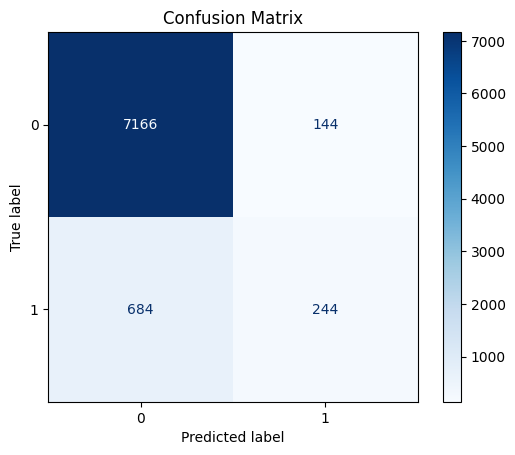

In [11]:
# Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

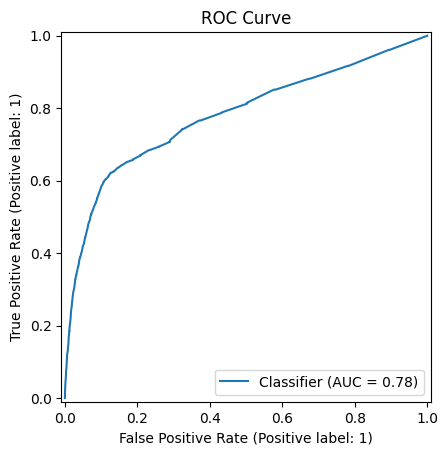

In [12]:
# ROC Curve

RocCurveDisplay.from_predictions(
    y_test,
    y_proba
)

plt.title("ROC Curve")
plt.show()

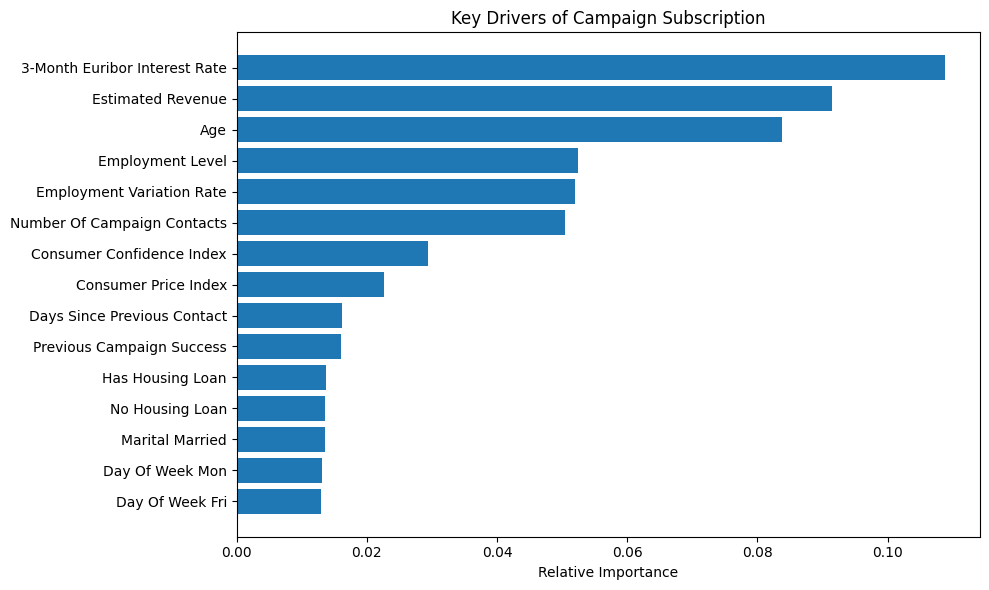

,feature,importance,feature_label
74,euribor3m,0.108764,3-Month Euribor Interest Rate
77,estimated_revenue,0.091491,Estimated Revenue
67,age,0.083735,Age
75,nr.employed,0.052498,Employment Level
71,emp.var.rate,0.051909,Employment Variation Rate
68,campaign,0.050447,Number Of Campaign Contacts
73,cons.conf.idx,0.029434,Consumer Confidence Index
72,cons.price.idx,0.022606,Consumer Price Index
69,pdays,0.016163,Days Since Previous Contact
52,poutcome_success,0.015991,Previous Campaign Success


In [13]:
# Feature Importance

encoded_cat_features = (
    pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = list(encoded_cat_features) + numeric_features

rf_model = pipeline.named_steps["model"]

feature_importance = pd.DataFrame(
    {
        "feature": all_feature_names,
        "importance": rf_model.feature_importances_
    }
).sort_values(
    by="importance",
    ascending=False
)

feature_label_map = {
    "euribor3m": "3-Month Euribor Interest Rate",
    "emp.var.rate": "Employment Variation Rate",
    "cons.price.idx": "Consumer Price Index",
    "cons.conf.idx": "Consumer Confidence Index",
    "nr.employed": "Employment Level",
    "campaign": "Number of Campaign Contacts",
    "pdays": "Days Since Previous Contact",
    "previous": "Previous Campaign Contacts",
    "estimated_revenue": "Estimated Revenue",
    "risk_score": "Risk Score",
    "age": "Age",
    "poutcome_success": "Previous Campaign Success",
    "poutcome_failure": "Previous Campaign Failure",
    "poutcome_nonexistent": "No Previous Campaign",
    "housing_yes": "Has Housing Loan",
    "housing_no": "No Housing Loan"
}

feature_importance["feature_label"] = (
    feature_importance["feature"]
    .replace(feature_label_map)
    .str.replace("_", " ", regex=False)
    .str.title()
)

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["feature_label"][::-1],
    top_features["importance"][::-1]
)

plt.title("Key Drivers of Campaign Subscription")
plt.xlabel("Relative Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

top_features

**"The model identified the 3-Month Euribor Interest Rate as the strongest predictor of campaign response. This doesn't necessarily imply that interest rates alone caused customers to subscribe, but rather that changes in the economic environment were highly associated with campaign outcomes in this dataset. This aligns with real-world banking, where market interest rates often influence customers' willingness to invest in products such as term deposits."**

In [14]:
# =====================================================
# Step 9: Streamlit Dashboard
# =====================================================

# The Streamlit dashboard is developed separately in app.py.
# It connects to the SQLite database and visualizes executive KPIs,
# client portfolio performance, campaign conversion, branch opportunity,
# and predictive analytics outputs.

print("Streamlit dashboard code is saved separately in app.py.")

Streamlit dashboard code is saved separately in app.py.


In [15]:
#updated app.py

%%writefile app.py

import streamlit as st
import pandas as pd
import sqlite3
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)


# =====================================================
# Formatting Helpers
# =====================================================

def format_currency(value):
    """Format currency values for executive dashboard display."""
    value = float(value)
    if abs(value) >= 1_000_000:
        return f"${value / 1_000_000:.1f}M"
    if abs(value) >= 1_000:
        return f"${value / 1_000:.1f}K"
    return f"${value:,.0f}"


def format_number(value):
    """Format large counts using K/M notation."""
    value = float(value)
    if abs(value) >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    if abs(value) >= 1_000:
        return f"{value / 1_000:.1f}K"
    return f"{value:,.0f}"


def add_currency_m_column(df, value_col, label_col):
    """Create a formatted currency label column for Plotly text labels."""
    df[label_col] = df[value_col].apply(format_currency)
    return df


def format_percent(value):
    return f"{float(value):.2f}%"

# =====================================================
# Page Config
# =====================================================

st.set_page_config(
    page_title="Business Banking Client Growth & Engagement Analytics",
    layout="wide"
)

st.title("Business Banking Client Growth & Engagement Analytics")
st.caption(
    "Executive Dashboard | Client Portfolio | Campaign Performance | Branch Opportunity | Predictive Analytics"
)

# =====================================================
# Load Data
# =====================================================

conn = sqlite3.connect("business_banking_analytics.db")
df = pd.read_csv("banking_processed.csv")

branch_df = pd.read_sql_query("SELECT * FROM vw_branch_performance", conn)
segment_df = pd.read_sql_query("SELECT * FROM vw_customer_segment_kpi", conn)
monthly_df = pd.read_sql_query("SELECT * FROM vw_monthly_campaign_trend", conn)
executive_kpis = pd.read_sql_query("SELECT * FROM vw_executive_kpis", conn)
executive_highlights = pd.read_sql_query("SELECT * FROM vw_executive_highlights", conn)
campaign_province_df = pd.read_sql_query("SELECT * FROM vw_campaign_province", conn)
previous_campaign_df = pd.read_sql_query("SELECT * FROM vw_previous_campaign_outcome", conn)
contact_duration_df = pd.read_sql_query("SELECT * FROM vw_contact_duration", conn)
branch_opportunity_df = pd.read_sql_query("SELECT * FROM vw_branch_opportunity", conn)
executive_action_df = pd.read_sql_query("SELECT * FROM vw_executive_action_center", conn)

# =====================================================
# Machine Learning Model
# =====================================================

df["target"] = df["y"].map({"yes": 1, "no": 0})

features = [
    "age", "job", "marital", "education",
    "default", "housing", "loan",
    "contact", "month", "day_of_week",
    "campaign", "pdays", "previous",
    "poutcome", "emp.var.rate", "cons.price.idx",
    "cons.conf.idx", "euribor3m", "nr.employed",
    "province", "branch_id", "risk_score",
    "estimated_revenue", "customer_segment"
]

X = df[features]
y = df["target"]

categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Feature importance
encoded_cat_features = (
    pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = list(encoded_cat_features) + numeric_features
rf_model = pipeline.named_steps["model"]

feature_importance = pd.DataFrame(
    {
        "feature": all_feature_names,
        "importance": rf_model.feature_importances_
    }
).sort_values("importance", ascending=False)

feature_label_map = {
    "euribor3m": "3-Month Euribor Interest Rate",
    "emp.var.rate": "Employment Variation Rate",
    "cons.price.idx": "Consumer Price Index",
    "cons.conf.idx": "Consumer Confidence Index",
    "nr.employed": "Employment Level",
    "campaign": "Number of Campaign Contacts",
    "pdays": "Days Since Previous Contact",
    "previous": "Previous Campaign Contacts",
    "estimated_revenue": "Estimated Revenue",
    "risk_score": "Risk Score",
    "age": "Age",
    "poutcome_success": "Previous Campaign Success",
    "poutcome_failure": "Previous Campaign Failure",
    "poutcome_nonexistent": "No Previous Campaign",
    "housing_yes": "Has Housing Loan",
    "housing_no": "No Housing Loan"
}

feature_importance["feature_label"] = (
    feature_importance["feature"]
    .replace(feature_label_map)
    .str.replace("_", " ", regex=False)
    .str.title()
)

# Priority customers
results = X_test.copy()
results["customer_id"] = df.loc[X_test.index, "customer_id"]
results["subscription_probability"] = y_proba
results["predicted_response"] = y_pred
results["actual_response"] = y_test.values

results = results.sort_values("subscription_probability", ascending=False)

# =====================================================
# Executive KPI Cards
# =====================================================

kpi = executive_kpis.iloc[0]

col1, col2, col3 = st.columns(3)

with col1:
    st.metric("Total Business Clients", format_number(kpi["total_business_clients"]))

with col2:
    st.metric("Total Revenue", format_currency(kpi["total_revenue"]))

with col3:
    st.metric("Campaign Conversion", f"{kpi['campaign_conversion_pct']:.2f}%")

col4, col5, col6 = st.columns(3)

with col4:
    st.metric("Portfolio Growth", f"{kpi['portfolio_growth_pct']:.1f}%")

with col5:
    st.metric("High Value Clients", format_number(kpi["high_value_clients"]))

with col6:
    st.metric("Digital Adoption", f"{kpi['digital_adoption_pct']:.2f}%")

# =====================================================
# Executive Insights
# =====================================================

highlight = executive_highlights.iloc[0]

st.subheader("Executive Insights")
st.caption("Automatically generated from client segment, branch, and campaign performance data.")

h1, h2 = st.columns(2)

with h1:
    st.success(f"""
**Highest Performing Client Segment**

### {highlight['highest_performing_segment']}

Avg Revenue: **{format_currency(highlight["highest_segment_revenue"])}**
Subscription Rate: **{highlight['highest_segment_conversion']:.2f}%**

**Recommendation:** Prioritize this segment for premium product cross-sell and relationship manager outreach.
""")

with h2:
    st.success(f"""
**Highest Growth Opportunity Branch**

### {highlight['highest_opportunity_region']}

Opportunity Score: **{highlight['highest_opportunity_score']:.2f}**

**Recommendation:** Prioritize this region for targeted growth actions based on revenue, client base, and untapped conversion potential.
""")

h3, h4 = st.columns(2)

with h3:
    st.success(f"""
**Highest Converting Campaign Period**

### {highlight['best_campaign']}

Conversion Rate: **{highlight['best_campaign_conversion']:.2f}%**

**Recommendation:** Review campaign timing, targeting, and contact strategy from this period before the next campaign cycle.
""")

with h4:
    st.warning(f"""
**Lowest Conversion Segment**

### {highlight['lowest_engagement_segment']}

Subscription Rate: **{highlight['lowest_segment_conversion']:.2f}%**

**Recommendation:** Improve messaging, offer design, or channel strategy before prioritizing this segment.
""")

st.divider()

# =====================================================
# Client Portfolio
# =====================================================

st.header("Client Portfolio")
st.caption("Which client segments generate the greatest business value?")

segment_df = add_currency_m_column(segment_df, "total_revenue", "total_revenue_label")
segment_df = add_currency_m_column(segment_df, "revenue_per_client", "revenue_per_client_label")

col1, col2 = st.columns(2)

with col1:
    st.subheader("Total Revenue by Client Segment")

    fig = px.bar(
        segment_df,
        x="customer_segment",
        y="total_revenue",
        color="customer_segment",
        text="total_revenue_label"
    )

    fig.update_traces(texttemplate="%{text}", textposition="outside")

    fig.update_layout(
        xaxis_title="Client Segment",
        yaxis_title="Total Revenue ($)",
        yaxis_tickprefix="$",
        yaxis_tickformat=".2s",
        showlegend=False,
        height=380,
        margin=dict(t=20, b=60, l=40, r=20)
    )

    st.plotly_chart(fig, use_container_width=True)

with col2:
    st.subheader("Client Portfolio Composition")

    fig = px.pie(
        segment_df,
        names="customer_segment",
        values="total_customers",
        hole=0.45
    )

    fig.update_traces(
        textinfo="label+percent",
        hovertemplate="<b>%{label}</b><br>Clients: %{value:,.0f}<br>Share: %{percent}<extra></extra>"
    )

    fig.update_layout(height=380, margin=dict(t=20, b=40, l=40, r=20))

    st.plotly_chart(fig, use_container_width=True)

col3, col4 = st.columns(2)

with col3:
    st.subheader("Estimated Revenue per Client by Segment")
    st.caption("This is an estimated client-value proxy from pre-campaign attributes, not monthly income.")

    fig = px.bar(
        segment_df,
        x="customer_segment",
        y="revenue_per_client",
        color="customer_segment",
        text="revenue_per_client_label"
    )

    fig.update_traces(texttemplate="%{text}", textposition="outside")

    fig.update_layout(
        xaxis_title="Client Segment",
        yaxis_title="Estimated Revenue per Client ($)",
        showlegend=False,
        height=380,
        margin=dict(t=20, b=60, l=40, r=20)
    )

    st.plotly_chart(fig, use_container_width=True)

with col4:
    st.subheader("Cross-Sell Opportunity by Segment")

    fig = px.bar(
        segment_df.sort_values("cross_sell_opportunity_score"),
        x="cross_sell_opportunity_score",
        y="customer_segment",
        orientation="h",
        text="cross_sell_opportunity_score"
    )

    fig.update_traces(texttemplate="%{text:.1f}", textposition="outside")

    fig.update_layout(
        xaxis_title="Opportunity Score",
        yaxis_title="Client Segment",
        height=380,
        margin=dict(t=20, b=40, l=40, r=40)
    )

    st.plotly_chart(fig, use_container_width=True)

st.divider()

# =====================================================
# Campaign Performance
# =====================================================

st.header("Campaign Performance Analytics")
st.caption("Which client groups, regions, and contact strategies drive campaign conversion? Campaign activity is uneven across months, so monthly peaks should be interpreted as campaign timing effects.")

month_order = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
month_labels = {
    "mar": "Mar", "apr": "Apr", "may": "May", "jun": "Jun", "jul": "Jul",
    "aug": "Aug", "sep": "Sep", "oct": "Oct", "nov": "Nov", "dec": "Dec"
}
monthly_df["month_label"] = monthly_df["month"].map(month_labels)
monthly_df["month"] = pd.Categorical(monthly_df["month"], categories=month_order, ordered=True)
monthly_df = monthly_df.sort_values("month")

col1, col2 = st.columns(2)

with col1:
    st.subheader("Monthly Campaign Conversion Trend")

    fig = px.line(
        monthly_df,
        x="month_label",
        y="conversion_rate_pct",
        markers=True
    )

    fig.update_layout(
        xaxis_title="Month",
        yaxis_title="Conversion Rate (%)",
        height=380,
        margin=dict(t=20, b=40, l=40, r=20)
    )

    st.plotly_chart(fig, use_container_width=True)

with col2:
    st.subheader("Conversion Rate by Client Segment")

    fig = px.bar(
        segment_df,
        x="customer_segment",
        y="subscription_rate_pct",
        color="customer_segment",
        text="subscription_rate_pct"
    )

    fig.update_traces(texttemplate="%{text:.2f}%", textposition="outside")

    fig.update_layout(
        xaxis_title="Client Segment",
        yaxis_title="Conversion Rate (%)",
        showlegend=False,
        height=380,
        margin=dict(t=20, b=60, l=40, r=20)
    )

    st.plotly_chart(fig, use_container_width=True)

col3, col4 = st.columns(2)

with col3:
    st.subheader("Campaign Success by Province")

    fig = px.bar(
        campaign_province_df.sort_values("conversion_rate_pct"),
        x="conversion_rate_pct",
        y="province",
        orientation="h",
        text="conversion_rate_pct"
    )

    fig.update_traces(texttemplate="%{text:.2f}%", textposition="outside")

    max_province_conversion = campaign_province_df["conversion_rate_pct"].max()

    fig.update_layout(
        xaxis_title="Conversion Rate (%)",
        yaxis_title="Province",
        height=380,
        margin=dict(t=20, b=40, l=40, r=90),
        xaxis_range=[0, max_province_conversion * 1.15]
    )

    st.plotly_chart(fig, use_container_width=True)

with col4:
    st.subheader("Impact of Previous Campaign Outcome on Conversion Rate")

    previous_campaign_df["previous_campaign_outcome"] = (
        previous_campaign_df["previous_campaign_outcome"]
        .replace({
            "success": "Previous Success",
            "failure": "Previous Failure",
            "nonexistent": "No Previous Campaign"
        })
    )

    fig = px.bar(
        previous_campaign_df,
        x="previous_campaign_outcome",
        y="conversion_rate_pct",
        color="previous_campaign_outcome",
        text="conversion_rate_pct"
    )

    fig.update_traces(texttemplate="%{text:.2f}%", textposition="outside")

    fig.update_layout(
        xaxis_title="Previous Campaign Outcome",
        yaxis_title="Current Conversion Rate (%)",
        showlegend=False,
        height=380,
        margin=dict(t=20, b=60, l=40, r=20)
    )

    st.plotly_chart(fig, use_container_width=True)

st.subheader("Call Duration by Conversion Outcome")
st.caption(
    "Diagnostic view only: call duration is known after the customer interaction, so it is shown for outcome analysis but excluded from the prediction model."
)

contact_duration_df["term_deposit_subscribed"] = (
    contact_duration_df["term_deposit_subscribed"]
    .replace({"yes": "Subscribed", "no": "Not Subscribed"})
)

duration_p95 = contact_duration_df["duration"].quantile(0.95)

fig = px.box(
    contact_duration_df,
    x="term_deposit_subscribed",
    y="duration",
    color="term_deposit_subscribed",
    points=False
)

fig.update_layout(
    xaxis_title="Campaign Outcome",
    yaxis_title="Call Duration (seconds)",
    showlegend=False,
    height=420,
    margin=dict(t=20, b=40, l=40, r=20),
    yaxis_range=[0, duration_p95]
)

st.plotly_chart(fig, use_container_width=True)
st.caption("Y-axis is capped at the 95th percentile to keep the box plots readable while reducing the visual impact of extreme call-duration outliers.")

st.divider()

# =====================================================
# Branch Performance
# =====================================================

st.header("Branch & Regional Performance")
st.caption("Which branches generate value, convert clients, and offer the highest growth opportunity?")

branch_opportunity_df = add_currency_m_column(branch_opportunity_df, "total_revenue", "total_revenue_label")
branch_opportunity_df = add_currency_m_column(branch_opportunity_df, "revenue_per_client", "revenue_per_client_label")

col1, col2 = st.columns(2)

with col1:
    st.subheader("Total Revenue by Branch")

    fig = px.bar(
        branch_opportunity_df,
        x="branch_name",
        y="total_revenue",
        color="province",
        text="total_revenue_label"
    )

    fig.update_traces(texttemplate="%{text}", textposition="outside")

    fig.update_layout(
        xaxis_title="Branch",
        yaxis_title="Total Revenue ($)",
        yaxis_tickprefix="$",
        yaxis_tickformat=".2s",
        height=380,
        margin=dict(t=20, b=70, l=40, r=20)
    )

    fig.update_xaxes(tickangle=20)

    st.plotly_chart(fig, use_container_width=True)

with col2:
    st.subheader("Campaign Conversion Rate by Branch")

    fig = px.bar(
        branch_opportunity_df,
        x="branch_name",
        y="conversion_rate_pct",
        color="province",
        text="conversion_rate_pct"
    )

    fig.update_traces(texttemplate="%{text:.2f}%", textposition="outside")

    fig.update_layout(
        xaxis_title="Branch",
        yaxis_title="Conversion Rate (%)",
        height=380,
        margin=dict(t=20, b=70, l=40, r=20)
    )

    fig.update_xaxes(tickangle=20)

    st.plotly_chart(fig, use_container_width=True)

col3, col4 = st.columns(2)

with col3:
    st.subheader("Branch Growth Opportunity Ranking")

    fig = px.bar(
        branch_opportunity_df.sort_values("branch_opportunity_score"),
        x="branch_opportunity_score",
        y="branch_name",
        orientation="h",
        text="branch_opportunity_score"
    )

    fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")

    max_branch_score = branch_opportunity_df["branch_opportunity_score"].max()

    fig.update_layout(
        xaxis_title="Opportunity Score",
        yaxis_title="Branch",
        height=380,
        margin=dict(t=20, b=40, l=40, r=90),
        xaxis_range=[0, max_branch_score * 1.12]
    )

    st.plotly_chart(fig, use_container_width=True)

with col4:
    st.subheader("Branch Opportunity Drivers")

    component_df = branch_opportunity_df[
        ["branch_name", "revenue_score", "client_base_score", "untapped_conversion_score"]
    ].melt(
        id_vars="branch_name",
        var_name="component",
        value_name="score"
    )

    component_df["component"] = component_df["component"].replace({
        "revenue_score": "Revenue Score",
        "client_base_score": "Client Base Score",
        "untapped_conversion_score": "Untapped Conversion Score"
    })

    fig = px.bar(
        component_df,
        x="branch_name",
        y="score",
        color="component",
        barmode="group"
    )

    fig.update_layout(
        xaxis_title="Branch",
        yaxis_title="Component Score",
        legend_title="",
        height=380,
        margin=dict(t=20, b=70, l=40, r=20)
    )

    fig.update_xaxes(tickangle=20)

    st.plotly_chart(fig, use_container_width=True)

st.divider()

# =====================================================
# Executive Action Center
# =====================================================

st.header("Executive Action Center")
st.caption("Growth opportunities and recommended actions by client segment and region.")

st.subheader("Detailed Opportunity Ranking")
st.caption("Full ranked table of growth opportunities by recommendation area. Use this for drill-down and prioritization details.")

display_cols = [
    "recommendation_area",
    "business_rule",
    "rank",
    "opportunity",
    "opportunity_score",
    "opportunity_potential",
    "recommended_action"
]

action_display_df = executive_action_df[display_cols].rename(
    columns={
        "recommendation_area": "Recommendation Area",
        "business_rule": "Business Rule",
        "rank": "Rank",
        "opportunity": "Opportunity",
        "opportunity_score": "Opportunity Score",
        "opportunity_potential": "Opportunity Potential",
        "recommended_action": "Recommended Action"
    }
)

st.dataframe(
    action_display_df,
    use_container_width=True,
    hide_index=True,
    height=420
)

st.subheader("Executive Action Summary Cards")
st.caption("Condensed executive summary of the top three opportunities and recommended action for each recommendation area.")

areas = executive_action_df["recommendation_area"].unique()
col1, col2 = st.columns(2)

for i, area in enumerate(areas):
    area_df = executive_action_df[
        executive_action_df["recommendation_area"] == area
    ].sort_values("rank")

    top = area_df.iloc[0]

    card = f"""
**Business Rule**

{top["business_rule"]}

---

**Top Opportunities**

1. {area_df.iloc[0]["opportunity"]} *(Score: {area_df.iloc[0]["opportunity_score"]:.1f})*
2. {area_df.iloc[1]["opportunity"]} *(Score: {area_df.iloc[1]["opportunity_score"]:.1f})*
3. {area_df.iloc[2]["opportunity"]} *(Score: {area_df.iloc[2]["opportunity_score"]:.1f})*

---

**Recommended Action**

{top["recommended_action"]}
"""

    if i % 2 == 0:
        with col1:
            with st.container(border=True):
                st.markdown(f"### {area}")
                st.markdown(card)
    else:
        with col2:
            with st.container(border=True):
                st.markdown(f"### {area}")
                st.markdown(card)

st.divider()

# =====================================================
# Predictive Analytics
# =====================================================

st.header("Predictive Analytics")
st.caption("Customer prioritization model for campaign conversion and outreach planning.")

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric("Accuracy", f"{accuracy:.2%}")

with col2:
    st.metric("Precision", f"{precision:.2%}")

with col3:
    st.metric("Recall", f"{recall:.2%}")

with col4:
    st.metric("ROC AUC", f"{roc_auc:.3f}")

st.caption("Model prioritizes customers most likely to subscribe, helping relationship managers focus outreach while reducing unnecessary campaign contact.")

col1, col2 = st.columns(2)

with col1:
    st.subheader("Confusion Matrix")

    cm = confusion_matrix(y_test, y_pred)

    cm_df = pd.DataFrame(
        cm,
        index=["Actual No", "Actual Yes"],
        columns=["Predicted No", "Predicted Yes"]
    )

    fig = px.imshow(
        cm_df,
        text_auto=True,
        color_continuous_scale="Blues"
    )

    fig.update_layout(height=380, margin=dict(t=20, b=40, l=40, r=20))

    st.plotly_chart(fig, use_container_width=True)

with col2:
    st.subheader("ROC Curve")

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)

    roc_df = pd.DataFrame(
        {
            "False Positive Rate": fpr,
            "True Positive Rate": tpr
        }
    )

    fig = px.line(
        roc_df,
        x="False Positive Rate",
        y="True Positive Rate"
    )

    fig.add_shape(
        type="line",
        x0=0,
        y0=0,
        x1=1,
        y1=1,
        line=dict(dash="dash")
    )

    fig.update_layout(height=380, margin=dict(t=20, b=40, l=40, r=20))

    st.plotly_chart(fig, use_container_width=True)

st.subheader("Key Drivers of Campaign Subscription")
st.caption(
    "Relative influence shows each variable's contribution to the Random Forest model, "
    "scaled as a percentage of total feature importance."
)

top_features = feature_importance.head(10).sort_values("importance").copy()
top_features["importance_pct"] = top_features["importance"] * 100

fig = px.bar(
    top_features,
    x="importance_pct",
    y="feature_label",
    orientation="h",
    text="importance_pct"
)

fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")

fig.update_layout(
    xaxis_title="Relative Influence (%)",
    yaxis_title="",
    height=430,
    margin=dict(t=20, b=40, l=40, r=90)
)

fig.update_xaxes(ticksuffix="%")

st.plotly_chart(fig, use_container_width=True)

st.subheader("Priority Outreach Sample")
st.caption(
    "Balanced sample showing top customers across priority tiers, rather than only the highest-scored customers. "
    "This supports tiered outreach planning for relationship managers and campaign teams."
)

priority_results = results.copy()

def priority_level(prob):
    if prob >= 0.97:
        return "Very High"
    elif prob >= 0.90:
        return "High"
    elif prob >= 0.80:
        return "Medium"
    else:
        return "Low"

def recommended_action(prob):
    if prob >= 0.97:
        return "Immediate Relationship Manager Follow-up"
    elif prob >= 0.90:
        return "Priority Campaign"
    elif prob >= 0.80:
        return "Standard Campaign"
    else:
        return "Monitor"

priority_results["priority_level"] = priority_results["subscription_probability"].apply(priority_level)
priority_results["recommended_action"] = priority_results["subscription_probability"].apply(recommended_action)

very_high_sample = (
    priority_results[priority_results["priority_level"] == "Very High"]
    .sort_values("subscription_probability", ascending=False)
    .head(8)
)

high_sample = (
    priority_results[priority_results["priority_level"] == "High"]
    .sort_values("subscription_probability", ascending=False)
    .head(6)
)

medium_sample = (
    priority_results[priority_results["priority_level"] == "Medium"]
    .sort_values("subscription_probability", ascending=False)
    .head(6)
)

priority_sample = pd.concat(
    [very_high_sample, high_sample, medium_sample],
    ignore_index=True
)

priority_sample["subscription_probability"] = (
    priority_sample["subscription_probability"] * 100
).round(1)
priority_sample["estimated_revenue"] = priority_sample["estimated_revenue"].apply(format_currency)
priority_sample["subscription_probability"] = priority_sample["subscription_probability"].map(lambda x: f"{x:.1f}%")

display_cols = [
    "customer_id",
    "province",
    "branch_id",
    "customer_segment",
    "estimated_revenue",
    "subscription_probability",
    "priority_level",
    "recommended_action"
]

priority_sample = priority_sample[display_cols].rename(
    columns={
        "customer_id": "Customer ID",
        "province": "Province",
        "branch_id": "Branch ID",
        "customer_segment": "Customer Segment",
        "estimated_revenue": "Estimated Revenue",
        "subscription_probability": "Subscription Probability",
        "priority_level": "Priority Level",
        "recommended_action": "Recommended Action"
    }
)

st.dataframe(
    priority_sample,
    use_container_width=True,
    hide_index=True
)

st.info(
    "Model insight: the outreach sample is grouped into Very High, High, and Medium priority tiers so teams can "
    "sequence relationship-manager follow-up and broader campaign outreach more realistically."
)

'''

Overwriting app.py


In [16]:
# =====================================================
# Final Project Output Checklist
# =====================================================

import os

required_files = [
    "banking_processed.csv",
    "business_banking_analytics.db",
    "app.py"
]

for file in required_files:
    if os.path.exists(file):
        print(f"✅ {file} is ready.")
    else:
        print(f"❌ {file} is missing.")

✅ banking_processed.csv is ready.
✅ business_banking_analytics.db is ready.
✅ app.py is ready.


In [17]:
# =====================================================
# Step 10: Deployment & Project Packaging Layer
# Create requirements.txt
# =====================================================

%%writefile requirements.txt
streamlit
pandas
numpy
plotly
scikit-learn
matplotlib

Overwriting requirements.txt


In [18]:
# =====================================================
# Create README.md
# =====================================================

%%writefile README.md
# Business Banking Client Growth & Engagement Analytics

## Project Overview

This project is an end-to-end business banking analytics solution built with Python, SQL, Machine Learning, and Streamlit.

It transforms raw banking campaign data into executive-ready insights through preprocessing, feature engineering, relational database design, reusable SQL KPI views, interactive dashboards, and predictive analytics.

The project simulates how a Canadian business banking team could use customer, campaign, branch, and economic data to identify growth opportunities, improve client engagement, and prioritize campaign outreach.

---

## Business Problem

Business banking teams need to understand which clients, regions, and campaign strategies offer the greatest opportunity for growth.

The objective of this project is to:

- Identify high-value client segments
- Analyze branch and regional performance
- Measure campaign conversion trends
- Surface cross-sell and growth opportunities
- Predict which clients are most likely to subscribe to a banking product
- Recommend executive actions by segment and region

---

## Solution Architecture

### Step 1 — Data Preparation & Feature Engineering

- Cleaned missing values
- Created customer IDs
- Added synthetic Canadian provinces and branch IDs
- Created risk score
- Created estimated revenue using pre-campaign customer attributes
- Created customer segments based on estimated revenue

### Step 2 — Relational SQL Database Design

Created normalized tables for:

- Customers
- Branches
- Financial Profiles
- Campaign Contacts
- Campaign Outcomes
- Economic Indicators

### Step 3 — SQLite Database Creation

Loaded normalized tables into a SQLite database.

### Step 4 — SQL Analytics & KPI Layer

Developed reusable SQL queries and views for:

- Branch performance
- Customer segment KPIs
- Monthly campaign trends
- Executive KPI cards
- Executive highlights
- Campaign performance by province
- Previous campaign outcome analysis
- Branch opportunity scoring
- Executive action recommendations

### Step 5 — Predictive Analytics Layer

Built a Random Forest classification model to predict customer subscription likelihood.

The model uses customer demographics, financial profile indicators, campaign history, branch information, customer value indicators, and economic variables.

To avoid target leakage, call duration was excluded from the predictive feature set.

### Step 6 — Streamlit Dashboard

Built an interactive Streamlit dashboard with:

- Executive KPI cards
- Executive insights
- Client portfolio analytics
- Campaign performance analytics
- Branch and regional performance
- Executive action center
- Predictive analytics model results
- Priority customer recommendations

---

## Technology Stack

- Python
- Pandas
- NumPy
- SQLite
- SQL
- Scikit-learn
- Plotly
- Streamlit
- Matplotlib

---

## Dashboard Features

### Executive Dashboard

- Total business clients
- Total estimated revenue
- Campaign conversion rate
- Portfolio growth
- High-value clients
- Digital adoption

### Client Portfolio

- Total revenue by client segment
- Client portfolio composition
- Revenue per client
- Cross-sell opportunity score

### Campaign Performance

- Monthly campaign conversion trend
- Conversion rate by client segment
- Campaign success by province
- Conversion by previous campaign outcome
- Call duration by conversion outcome

### Branch & Regional Performance

- Total revenue by branch
- Campaign conversion rate by branch
- Branch growth opportunity ranking
- Branch opportunity drivers

### Executive Action Center

- Growth opportunities by recommendation area
- Business rules
- Opportunity scores
- Recommended executive actions

### Predictive Analytics

- Accuracy
- Precision
- Recall
- ROC AUC
- Confusion matrix
- ROC curve
- Key drivers of campaign subscription
- Top priority customers for outreach

---

## Machine Learning Approach

The predictive model estimates the likelihood of customer subscription using a Random Forest classifier.

Key modeling decisions:

- Excluded call duration to avoid target leakage
- Included estimated revenue because it was engineered from pre-campaign attributes
- Included customer segment as a business value indicator
- Used class weighting to handle imbalance between subscribers and non-subscribers

Key predictive drivers include:

- 3-Month Euribor Interest Rate
- Estimated Revenue
- Age
- Employment Indicators
- Campaign Contact History
- Consumer Confidence
- Previous Campaign Outcome

---

## Business Value

This project demonstrates how analytics can support business banking decision-making by helping teams:

- Prioritize high-value client segments
- Identify under-converted growth opportunities
- Improve campaign targeting
- Support relationship manager outreach
- Monitor branch-level performance
- Convert predictive model outputs into actionable recommendations

---

## Future Enhancements

- Hyperparameter tuning
- Model calibration
- SHAP-based explainability
- Customer lifetime value modeling
- Multi-product recommendation engine
- Cloud database integration
- Automated data refresh
- Role-based dashboard views

---

## Author

**Mahdieh Ghafourian (Aylin)**

Toronto, Ontario, Canada

Data Analytics | Business Intelligence | Machine Learning

Overwriting README.md
